<a class="cbe-colab-launch" href="https://colab.research.google.com/github/tlliuca/AI4ChemEng/blob/main/dsmles/participation/participation-11-clustering.ipynb" target="_blank" rel="noopener noreferrer" title="Open this notebook in Google Colab (opens in a new tab)">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="146" height="25">
</a>

In [ ]:
# Run this cell first in a fresh notebook environment.
%pip install -q "numpy<2.4" pandas matplotlib scikit-learn pycse shap xgboost umap-learn jupyterquiz==2.9.6.2 uncertainties

In [ ]:
# Included CBE 4427 data; no original-course server is contacted.
from pathlib import Path
import base64, json, tempfile, zlib
_course_embedded = json.loads(zlib.decompress(base64.b64decode('eNqrrgUAAXUA+Q==')))
_course_cache = Path(tempfile.mkdtemp(prefix="cbe4427-"))
def course_file(name):
    """Use a local course file, or the copy embedded in this notebook."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [root / "dsmles" / name, root / name]:
            if candidate.is_file():
                return str(candidate)
    if name not in _course_embedded:
        raise FileNotFoundError("Course resource not included: " + name)
    target = (_course_cache / name).resolve()
    if _course_cache not in target.parents:
        raise ValueError("Invalid course resource path")
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.exists():
        target.write_text(_course_embedded[name])
    return str(target)


```{note}
Practice resource for CBE 4427. Your instructor specifies assigned activities, deadlines, submission requirements, and assessment criteria. Example points or rubrics below are part of the practice material.
```

# Module 11: Clustering - Participation Exercises

## Exercise 11.1: Prediction - How Many Clusters?

**Type:** 🔮 Prediction (3 min)

You have process data from a reactor that operates in three known modes: startup, steady-state, and shutdown. You apply k-means.

**Predict:** Will k-means with k=3 find clusters that match the three operating modes?

- [ ] Yes, definitely
- [ ] Probably, if the modes are well-separated
- [ ] Probably not, clusters aren't always meaningful
- [ ] No, k-means can't find interpretable clusters

**Explain your reasoning.**

*Your prediction and reasoning:*



## Exercise 11.2: Mini-Exercise - Scaling Impact

**Type:** 🔧 Mini-Exercise (6 min)

See how scaling affects k-means clustering.

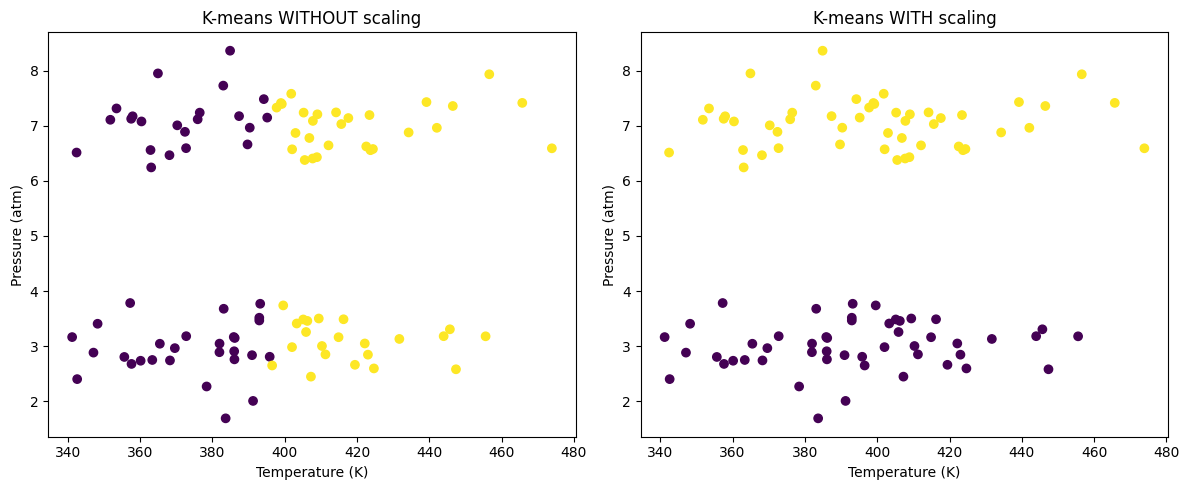

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Two features with very different scales
np.random.seed(42)
n = 100

# Temperature (300-500 K) and pressure (1-10 atm)
# Two natural clusters based on pressure
cluster1 = np.column_stack([
    np.random.normal(400, 30, n//2),  # temperature
    np.random.normal(3, 0.5, n//2)    # pressure
])
cluster2 = np.column_stack([
    np.random.normal(400, 30, n//2),  # temperature
    np.random.normal(7, 0.5, n//2)    # pressure
])
X = np.vstack([cluster1, cluster2])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Without scaling
kmeans_unscaled = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_unscaled = kmeans_unscaled.fit_predict(X)
axes[0].scatter(X[:, 0], X[:, 1], c=labels_unscaled, cmap='viridis')
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Pressure (atm)')
axes[0].set_title('K-means WITHOUT scaling')

# With scaling
X_scaled = StandardScaler().fit_transform(X)
kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)
axes[1].scatter(X[:, 0], X[:, 1], c=labels_scaled, cmap='viridis')
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel('Pressure (atm)')
axes[1].set_title('K-means WITH scaling')

plt.tight_layout()
plt.show()

# TASK: Explain the difference. Which clustering is "correct"?

*Your explanation:*



## Exercise 11.3: Discussion - Clustering Without Ground Truth

**Type:** 💬 Discussion (5 min)

Clustering is unsupervised - there are no labels to tell us if we're right.

**Discuss:**
1. How do you validate clusters without ground truth?
2. When might silhouette score be misleading?
3. What role does domain expertise play in evaluating clusters?

*Discussion notes:*

